# **Telecom X – Customer Churn Analysis**

## Data Science Challenge

This project analyzes customer churn data from the fictional company **Telecom X**.  
The goal is to explore the data, identify patterns related to customer churn, and generate insights that could help the company reduce customer loss.

The analysis will follow a typical data science workflow including:

- Data extraction
- Data cleaning
- Exploratory Data Analysis (EDA)
- Insight generation

## **Business Objective**

Telecom X is experiencing a high rate of customer churn and needs to understand the factors that contribute to customer cancellations.

The objective of this analysis is to:

- Extract customer data from an API
- Transform the data into a usable format
- Perform exploratory data analysis (EDA)
- Identify potential drivers of customer churn

The insights generated from this analysis could help the company develop strategies to improve customer retention.


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Data

In [3]:
data = pd.read_json('/content/drive/MyDrive/Telecom_Parte_1/TelecomX_Data.json')
data

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


## Initial Data Inspection

In [4]:
data.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [6]:
data.shape

(7267, 6)

In [7]:
data.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


## Flattening nested JSON

In [8]:
customer = pd.json_normalize(data['customer'])
phone = pd.json_normalize(data['phone'])
internet = pd.json_normalize(data['internet'])
account = pd.json_normalize(data['account'])

In [9]:
telecom_df = pd.concat(
    [data[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

telecom_df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [10]:
telecom_df.columns


Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

## Data Quality Inspection

In [11]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [12]:
telecom_df.duplicated().sum()

np.int64(0)

In [13]:
telecom_df.describe()

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [14]:
telecom_df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


##Data Cleaning

let's change the Charges.total column from object to numeric

In [15]:
from IPython.core import error
telecom_df['Charges.Total'] = pd.to_numeric(telecom_df['Charges.Total'],errors='coerce')

In [16]:
telecom_df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [17]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Let’s replace the new NaN values in the Charges.Total integer column with 0, since these clients are likely new and haven’t made any payments yet.

In [18]:
telecom_df['Charges.Total'] = telecom_df['Charges.Total'].fillna(0)

In [19]:
telecom_df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


## Exploratory Data Analysis (EDA)

###Correlation

In [28]:
correlation = telecom_df[["tenure","Charges.Monthly","Charges.Total"]]

correlation.corr()

,tenure,Charges.Monthly,Charges.Total
tenure,1.000000,0.247982,0.825407
Charges.Monthly,0.247982,1.000000,0.652211
Charges.Total,0.825407,0.652211,1.000000


### Churn Distribution

**Customer churn refers to the percentage of customers who stop using a company's services during a given period.**

In this dataset, the **Churn** variable indicates whether a customer has canceled their service:

- **Yes** → the customer left the company
- **No** → the customer is still active

Understanding the distribution of churn is important to evaluate how serious the customer loss problem is for Telecom X.

In [20]:
telecom_df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [21]:
telecom_df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In these results, we can see that **25.7%** of clients have left the service, which is a high number for the telecom industry, where companies usually aim for less than 10% churn. So we do have a problem here....

##**Which type of customers churn the most?**.
##Churn by contract type

Contract type can influence customer churn behavior. Customers with short-term contracts may have a higher probability of canceling the service compared to those with long-term agreements.

This analysis explores how churn varies depending on the customer's contract type.

In [22]:
pd.crosstab(telecom_df['Contract'], telecom_df['Churn'], normalize='index')*100

Churn,,No,Yes
Contract,,,
Month-to-month,3.245943,55.430712,41.323346
One year,3.028308,86.043450,10.928242
Two year,2.753873,94.492255,2.753873


In [23]:
sns.set_palette('pastel')

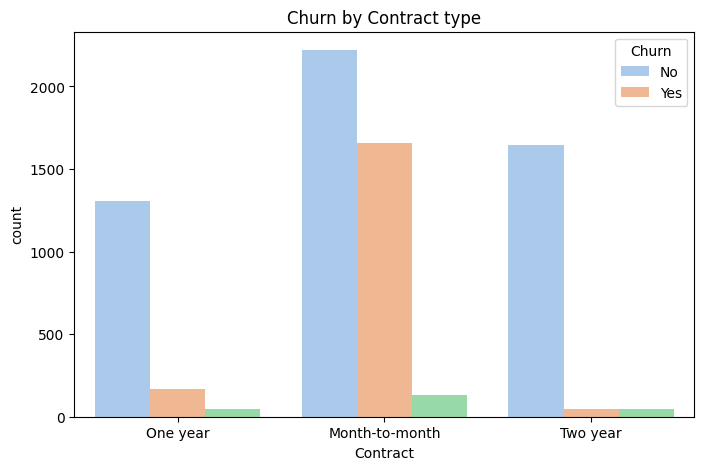

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=telecom_df, x='Contract', hue='Churn')
plt.title('Churn by Contract type')
plt.show()

### Churn by Internet Service

Internet service type may influence customer satisfaction and churn behavior.

Technologies such as DSL or Fiber optic can offer different performance levels, prices, and reliability, which may affect whether customers decide to stay or cancel the service.

This analysis explores how churn varies across different internet service types.

In [25]:
pd.crosstab(telecom_df['InternetService'], telecom_df['Churn'], normalize='index') * 100

Churn,,No,Yes
InternetService,,,
DSL,2.692926,78.858521,18.448553
Fiber optic,3.189493,56.253909,40.556598
No,3.478811,89.373814,7.147375


/tmp/ipykernel_478/3466194681.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


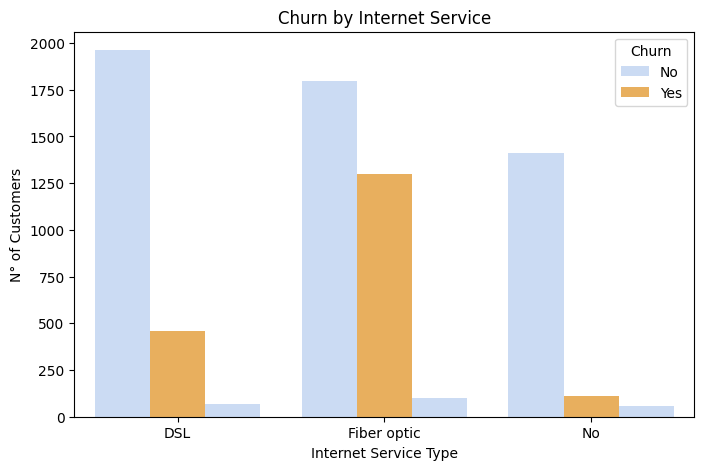

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=telecom_df,
    x='InternetService',
    hue='Churn',
    palette=['#c4dafa','#ffb347']
)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('N° of Customers')

plt.show()


Customers with **Fiber optic internet service show the highest churn rate**, reaching approximately **40%**, compared to **18% for DSL** and **7% for customers without internet service**.

This may indicate that fiber optic customers have higher expectations regarding service quality and performance. If these expectations are not met, customers may be more likely to cancel their service.

Another possible explanation is that fiber optic plans may be more expensive, which could lead customers to reconsider their subscription if they do not perceive enough value.

### **Churn by Customer Tenure**

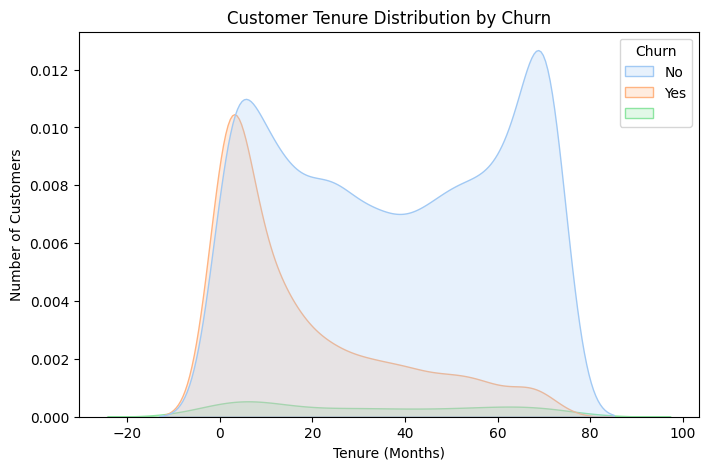

In [58]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=telecom_df,
    x='tenure',
    hue='Churn',
    fill=True

)

plt.title('Customer Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()


The histogram shows that customer churn is more concentrated among customers with **lower tenure**, especially during the first months of service.

As tenure increases, the number of customers who churn decreases significantly. This suggests that **new customers are more likely to cancel their subscription**, while long-term customers tend to remain loyal to the service.

This pattern indicates that the **early customer experience may play an important role in customer retention**.

### Churn by Payment Method

In [29]:
pd.crosstab(telecom_df['PaymentMethod'], telecom_df['Churn'], normalize='index')*100

Churn,,No,Yes
PaymentMethod,,,
Bank transfer (automatic),2.831970,80.931403,16.236627
Credit card (automatic),2.933673,82.270408,14.795918
Electronic check,3.271984,52.924335,43.803681
Mailed check,3.183183,78.318318,18.498498


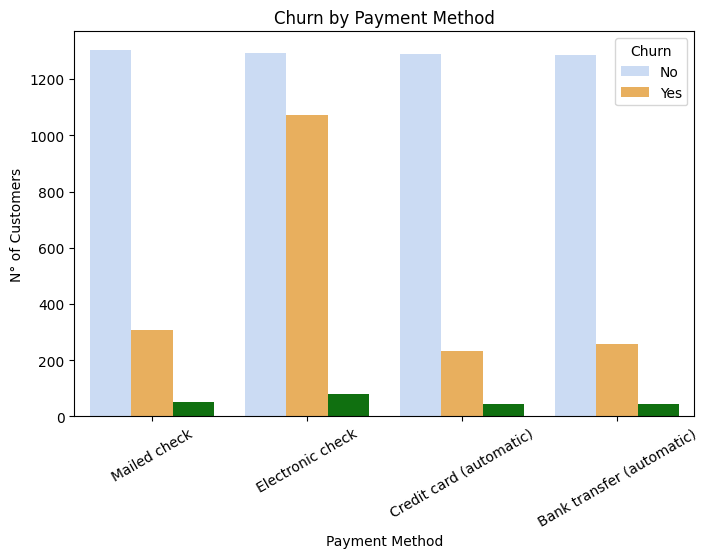

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=telecom_df,
    x='PaymentMethod',
    hue='Churn',
    palette=['#c4dafa','#ffb347','green']
)

plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('N° of Customers')
plt.xticks(rotation = 30)

plt.show()

The analysis shows that customers using **electronic check** as their payment method have the highest churn rate, reaching approximately **44%**, which is significantly higher than other payment methods.

In contrast, customers using **automatic payment methods**, such as bank transfer or credit card, show much lower churn rates (around 14–16%).

This pattern suggests that customers who use automatic payments may be more committed to the service, while customers paying through electronic checks may have lower engagement or may find it easier to discontinue the service.

## Monthly Charges vs Churn

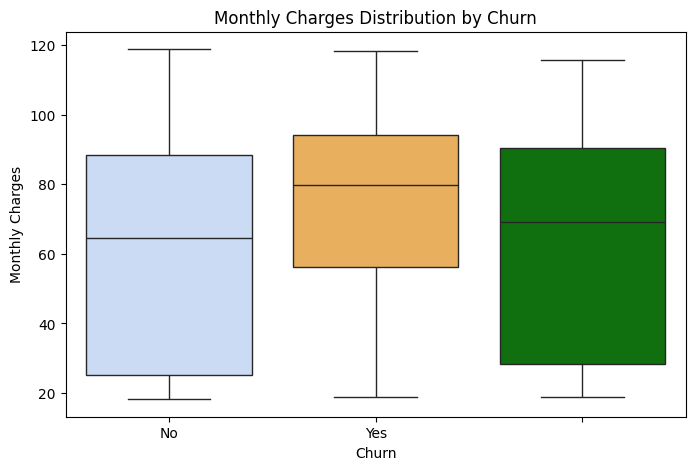

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=telecom_df,
    x='Churn',
    y='Charges.Monthly',
    hue='Churn',
    palette=["#c4dafa","#ffb347","green"],
    legend=False
)

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()


The boxplot shows that customers who churn tend to have **higher monthly charges** compared to customers who remain with the company.

The median monthly charge for churned customers is noticeably higher than for retained customers. This suggests that **higher service costs may be associated with an increased likelihood of customer churn**.

This pattern may indicate that customers paying higher prices may be more sensitive to service quality or may perceive lower value for the cost.

## Conclusions and Insights based on the analysis

The exploratory analysis revealed several factors associated with customer churn.

1. First, customers with **month-to-month contracts** show a significantly higher churn rate compared to customers with one-year or two-year contracts. This suggests that longer contracts increase customer retention.

2. Second, customers using **fiber optic internet service** tend to churn more frequently than those using DSL or those without internet service. This may indicate that customers with higher-priced services have higher expectations or are more sensitive to service quality.

3. Another important finding is related to **payment methods**. Customers who pay using **electronic checks** have the highest churn rate, while those using automatic payments such as credit cards or bank transfers show lower churn rates. This may suggest that automatic payment methods are associated with more committed customers.

$. Additionally, customers with **shorter tenure** tend to churn more frequently, indicating that the first months of the customer lifecycle are critical for retention.

6. Finally, the analysis shows that customers with **higher monthly charges** tend to churn more often, suggesting that pricing may influence customer decisions to stay or leave the service.

Overall, these insights highlight several opportunities for improving customer retention strategies.

## Business Recommendations

Based on the analysis, we can implement some specific actions that could help reduce customer churn:

- Encourage customers to switch from month-to-month contracts to longer-term plans through discounts or incentives.
- Promote automatic payment methods such as credit card or bank transfer to increase customer commitment.
- Review pricing strategies for higher-cost services such as fiber optic plans.
- Focus retention efforts on new customers during the first months of their subscription, by offering new offers for example.